# 🌾 Multimodal Geospatial TransFarmer — Demo Presentation

**A multimodal framework for crop disease detection and pest density estimation**  
Fusing UAV imagery · IoT micro-climate sensors · Geospatial embeddings

---
> **Run All Cells** (Kernel → Restart & Run All) to reproduce every figure end-to-end.

## Cell 1 — Imports & Global Config

In [1]:
from __future__ import annotations

import copy, random, time, warnings
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import torch
from torch import Tensor, nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings('ignore')

try:
    from torchvision import transforms
    _TV = True
except Exception:
    transforms = None
    _TV = False

# ── Global config ──────────────────────────────────────────────────────────────
SEED          = 42
EPOCHS        = 15
TRAIN_SAMPLES = 1024
EVAL_SAMPLES  = 256
IMAGE_SIZE    = 96
BATCH_SIZE    = 32
DIM           = 96
TELEMETRY_T   = 24          # 24 hourly steps
OUTPUT_DIR    = Path('outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Reproducibility ────────────────────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print(f'Config : {EPOCHS} epochs · {TRAIN_SAMPLES} train · {EVAL_SAMPLES} eval · dim={DIM}')

Device : cpu
PyTorch: 2.6.0+cpu
Config : 15 epochs · 1024 train · 256 eval · dim=96


## Cell 2 — Model Architecture (Inline)
All components are defined here so the notebook is fully self-contained.

In [2]:
# ── Vision backbone ────────────────────────────────────────────────────────────
class TinyVisionBackbone(nn.Module):
    """3-layer CNN → spatial feature map (B, D, H/8, W/8)."""
    def __init__(self, dim: int = DIM) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 24, 3, 2, 1), nn.BatchNorm2d(24), nn.ReLU(),
            nn.Conv2d(24, 48, 3, 2, 1), nn.BatchNorm2d(48), nn.ReLU(),
            nn.Conv2d(48, dim, 3, 2, 1), nn.BatchNorm2d(dim), nn.ReLU(),
        )
        self.dim = dim
    def forward(self, x: Tensor) -> Tensor:
        return self.net(x)


# ── Cross-modal attention ──────────────────────────────────────────────────────
class CrossModalAttention(nn.Module):
    """Visual tokens as Q; environmental context as K, V."""
    def __init__(self, dim: int = DIM) -> None:
        super().__init__()
        self.q = nn.Linear(dim, dim)
        self.k = nn.Linear(dim, dim)
        self.v = nn.Linear(dim, dim)
        self.out = nn.Linear(dim, dim)
        self.scale = dim ** -0.5
    def forward(self, visual: Tensor, env: Tensor) -> tuple[Tensor, Tensor]:
        attn = torch.softmax((self.q(visual) @ self.k(env).transpose(1, 2)) * self.scale, dim=-1)
        return self.out(attn @ self.v(env)), attn


# ── Full multimodal regressor ──────────────────────────────────────────────────
class TransFarmer(nn.Module):
    """
    Inputs:
        image      : (B, 3, H, W)  — UAV crop image
        telemetry  : (B, T, 3)     — hourly [temp, humidity, soil_moisture]
        trap_count : (B, 1)        — IoT trap sensor scalar
    Output:
        pest_density : (B, 1)
    """
    def __init__(self, dim: int = DIM) -> None:
        super().__init__()
        self.vision   = TinyVisionBackbone(dim)
        self.lstm     = nn.LSTM(3, dim, batch_first=True)
        self.trap_enc = nn.Sequential(nn.Linear(1, dim), nn.ReLU(), nn.Linear(dim, dim))
        self.fusion   = CrossModalAttention(dim)
        self.head     = nn.Sequential(
            nn.Linear(dim * 2, dim), nn.ReLU(), nn.Dropout(0.1), nn.Linear(dim, 1)
        )

    def forward(
        self,
        image: Tensor,
        telemetry: Tensor,
        trap_count: Tensor,
        return_fmap: bool = False,
    ):
        fmap = self.vision(image)
        if return_fmap:
            fmap.retain_grad()
        vis_tok = fmap.flatten(2).transpose(1, 2)           # (B, N, D)
        _, (h, _) = self.lstm(telemetry)                    # h: (1, B, D)
        env = torch.stack([h[-1], self.trap_enc(trap_count)], dim=1)  # (B, 2, D)
        attended, attn_w = self.fusion(vis_tok, env)
        pred = self.head(torch.cat([vis_tok.mean(1), attended.mean(1)], dim=1))
        return (pred, fmap, attn_w) if return_fmap else pred


model = TransFarmer(DIM).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'TransFarmer — {total_params:,} parameters')
print(model)

TransFarmer — 157,153 parameters
TransFarmer(
  (vision): TinyVisionBackbone(
    (net): Sequential(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(24, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): ReLU()
    )
  )
  (lstm): LSTM(3, 96, batch_first=True)
  (trap_enc): Sequential(
    (0): Linear(in_features=1, out_features=96, bias=True)
    (1): ReLU()
    (2): Linear(in_features=96, out_features=96, bias=True)
  )
  (fusion): CrossModalAttention(
    (q): Linear(in_features=96, out_features=96, bias=True)
    (k): Linear(in_features=96, ou

## Cell 3 — Data
Deterministic UAV-like images + 24-hour IoT telemetry sequences with realistic diurnal curves.

In [3]:
def make_telemetry(idx: int, seed: int):
    rng  = np.random.default_rng(seed + idx * 7919)
    hour = np.arange(TELEMETRY_T, dtype=np.float32)
    ph   = rng.uniform(-0.7, 0.7)
    temp = np.clip(27 + rng.normal(0, 2.2) + 6 * np.sin((hour - 8) * np.pi / 12 + ph), 12, 45)
    hum  = np.clip(72 + rng.normal(0, 5) - 0.9 * (temp - 27) + 5 * np.sin(hour * np.pi / 12 + ph), 25, 99)
    soil = np.clip(38 + rng.normal(0, 7) + 4 * np.sin((hour - 4) * np.pi / 12 + ph / 2), 5, 85)
    fav  = np.maximum(temp - 21, 0) * (hum / 100) * (0.5 + soil / 200)
    traps = float(rng.poisson(1.0 + 0.32 * fav.mean()))
    density = float(max(0, 1.8 * fav.mean() + 2.7 * traps + rng.normal(0, 1.4)))
    return np.stack([temp, hum, soil], axis=-1).astype(np.float32), traps, density


class PestDataset(Dataset):
    def __init__(self, length: int, seed: int) -> None:
        self.length, self.seed = length, seed
        self.norm = transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)) if _TV else None

    def __len__(self): return self.length

    def _uav_image(self, idx: int, density: float) -> Tensor:
        g = torch.Generator().manual_seed(self.seed + idx)
        img = torch.empty(3, IMAGE_SIZE, IMAGE_SIZE).uniform_(0.05, 0.3, generator=g)
        img[1] += 0.28                                          # green canopy
        spots = min(30, max(1, int(density / 2)))
        for _ in range(spots):
            y = int(torch.randint(3, IMAGE_SIZE - 3, (1,), generator=g))
            x = int(torch.randint(3, IMAGE_SIZE - 3, (1,), generator=g))
            img[0, y-2:y+3, x-2:x+3] += 0.55                  # reddish lesion spot
            img[1, y-2:y+3, x-2:x+3] -= 0.15
        return img.clamp(0, 1)

    def __getitem__(self, idx: int):
        tel, traps, density = make_telemetry(idx, self.seed)
        img = self._uav_image(idx, density)
        if self.norm: img = self.norm(img)
        return {
            'image':      img.float(),
            'telemetry':  torch.from_numpy(tel),
            'trap_count': torch.tensor([traps], dtype=torch.float32),
            'density':    torch.tensor([density], dtype=torch.float32),
        }


train_ds = PestDataset(TRAIN_SAMPLES, SEED)
eval_ds  = PestDataset(EVAL_SAMPLES,  SEED + 100_000)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
eval_loader  = DataLoader(eval_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {len(train_ds)} samples | Eval: {len(eval_ds)} samples')

# Quick sanity check on shapes
sample_batch = next(iter(train_loader))
for k, v in sample_batch.items():
    print(f'  {k:12s}: {tuple(v.shape)}')

Train: 1024 samples | Eval: 256 samples
  image       : (32, 3, 96, 96)
  telemetry   : (32, 24, 3)
  trap_count  : (32, 1)
  density     : (32, 1)


## Cell 4 — Training Loop
Trains the model and records per-epoch MSE loss for the learning curve plot.

In [4]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    ep_losses = []
    for batch in train_loader:
        b = {k: v.to(DEVICE) for k, v in batch.items()}
        optimizer.zero_grad(set_to_none=True)
        pred = model(b['image'], b['telemetry'], b['trap_count'])
        loss = F.mse_loss(pred, b['density'])
        loss.backward()
        optimizer.step()
        ep_losses.append(loss.item())
    scheduler.step()
    train_losses.append(float(np.mean(ep_losses)))

    # ── Validate ──
    model.eval()
    with torch.no_grad():
        vl = []
        for batch in eval_loader:
            b = {k: v.to(DEVICE) for k, v in batch.items()}
            vl.append(F.mse_loss(model(b['image'], b['telemetry'], b['trap_count']), b['density']).item())
        val_losses.append(float(np.mean(vl)))

    print(f'Epoch {epoch:2d}/{EPOCHS} | Train MSE: {train_losses[-1]:.4f} | Val MSE: {val_losses[-1]:.4f}')

print('\nTraining complete.')

Epoch  1/15 | Train MSE: 46.5539 | Val MSE: 12.1594
Epoch  2/15 | Train MSE: 5.7930 | Val MSE: 5.2585
Epoch  3/15 | Train MSE: 4.3102 | Val MSE: 3.7538
Epoch  4/15 | Train MSE: 3.8226 | Val MSE: 3.5032
Epoch  5/15 | Train MSE: 3.3696 | Val MSE: 4.8065
Epoch  6/15 | Train MSE: 2.6871 | Val MSE: 2.8415
Epoch  7/15 | Train MSE: 2.2931 | Val MSE: 2.7415
Epoch  8/15 | Train MSE: 1.8557 | Val MSE: 2.5279
Epoch  9/15 | Train MSE: 1.6456 | Val MSE: 2.7860
Epoch 10/15 | Train MSE: 1.5418 | Val MSE: 2.4029
Epoch 11/15 | Train MSE: 1.3550 | Val MSE: 2.3551
Epoch 12/15 | Train MSE: 1.4937 | Val MSE: 2.3278
Epoch 13/15 | Train MSE: 1.2854 | Val MSE: 2.3201
Epoch 14/15 | Train MSE: 1.1916 | Val MSE: 2.2831
Epoch 15/15 | Train MSE: 1.1208 | Val MSE: 2.2935

Training complete.


## 📊 Figure 1 — Learning Curve (Train vs Validation MSE)

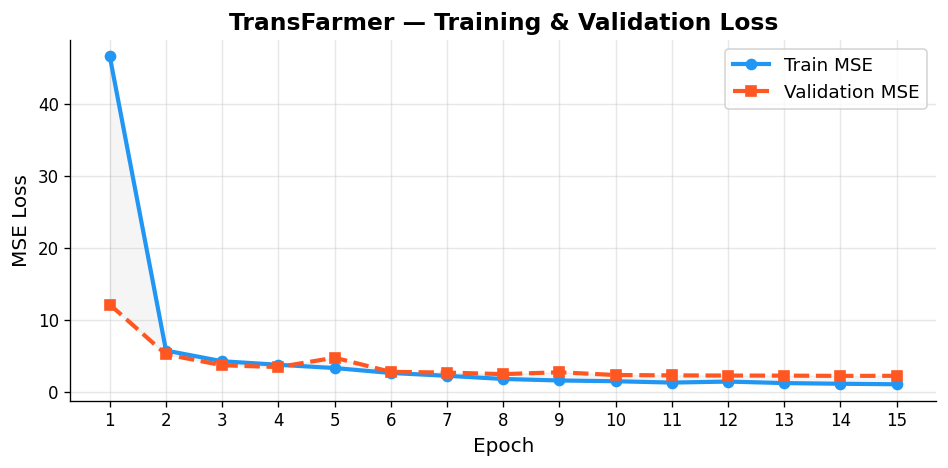

Best Val MSE: 2.2831 at epoch 14


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
epochs_x = range(1, EPOCHS + 1)
ax.plot(epochs_x, train_losses, 'o-', color='#2196F3', linewidth=2.5, markersize=6, label='Train MSE')
ax.plot(epochs_x, val_losses,   's--', color='#FF5722', linewidth=2.5, markersize=6, label='Validation MSE')
ax.fill_between(epochs_x, train_losses, val_losses, alpha=0.08, color='gray')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('TransFarmer — Training & Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(list(epochs_x))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_learning_curve.png', bbox_inches='tight')
plt.show()
print(f'Best Val MSE: {min(val_losses):.4f} at epoch {val_losses.index(min(val_losses)) + 1}')

## Cell 5 — Evaluation Metrics

In [6]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for batch in eval_loader:
        b = {k: v.to(DEVICE) for k, v in batch.items()}
        all_preds.extend(model(b['image'], b['telemetry'], b['trap_count']).squeeze(1).cpu().tolist())
        all_targets.extend(b['density'].squeeze(1).cpu().tolist())

preds   = np.array(all_preds)
targets = np.array(all_targets)
residuals = preds - targets

MAE  = float(np.abs(residuals).mean())
RMSE = float(np.sqrt(np.mean(residuals ** 2)))
R2   = float(1 - np.sum(residuals ** 2) / max(np.sum((targets - targets.mean()) ** 2), 1e-8))

print('=' * 40)
print(f'  MAE  : {MAE:.4f}')
print(f'  RMSE : {RMSE:.4f}')
print(f'  R²   : {R2:.4f}')
print('=' * 40)

  MAE  : 1.2247
  RMSE : 1.5144
  R²   : 0.8953


## 📊 Figure 2 — Predicted vs Actual Pest Density + Metrics Panel

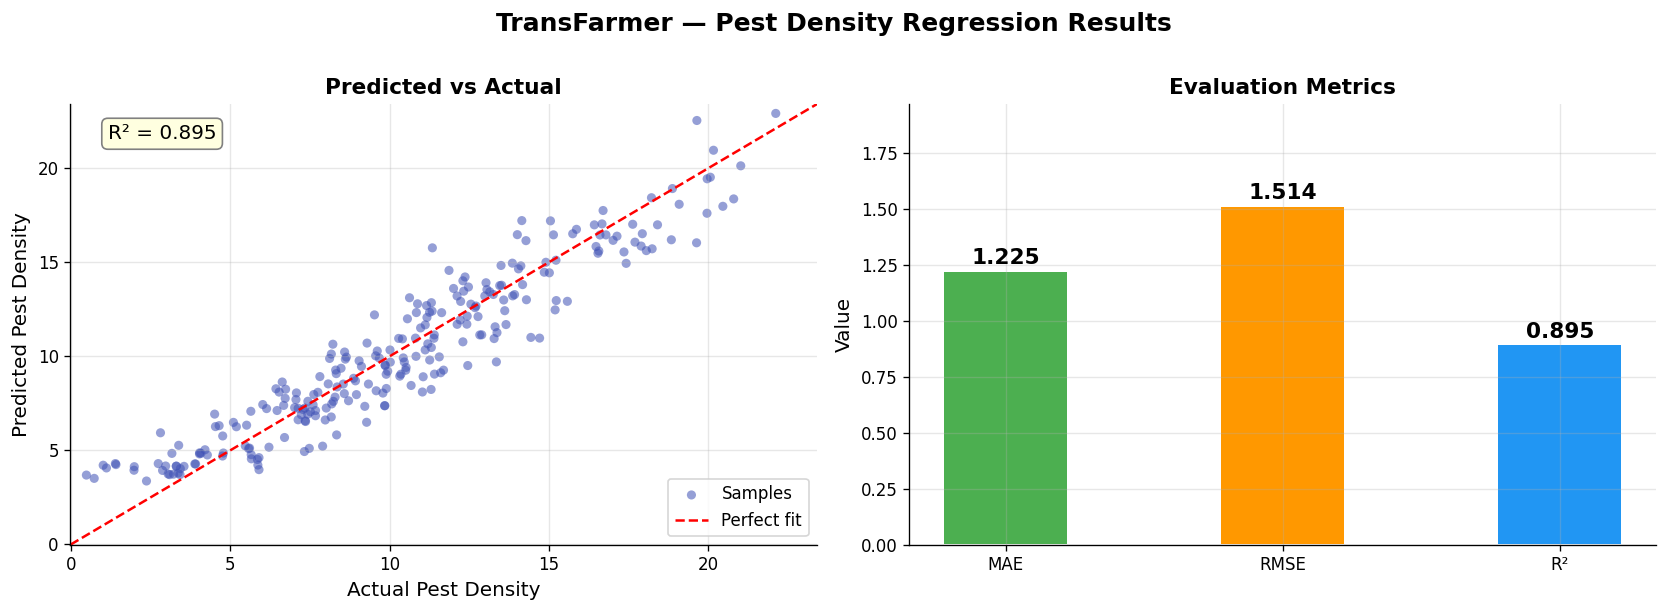

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: scatter predicted vs actual ─────────────────────────────────────────
ax = axes[0]
ax.scatter(targets, preds, alpha=0.55, s=30, color='#3F51B5', edgecolors='none', label='Samples')
lims = [min(targets.min(), preds.min()) - 0.5, max(targets.max(), preds.max()) + 0.5]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual Pest Density', fontsize=12)
ax.set_ylabel('Predicted Pest Density', fontsize=12)
ax.set_title('Predicted vs Actual', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.text(0.05, 0.92, f'R² = {R2:.3f}', transform=ax.transAxes, fontsize=12,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

# ── Right: metrics bar chart ───────────────────────────────────────────────────
ax2 = axes[1]
metrics_names = ['MAE', 'RMSE', 'R²']
metrics_vals  = [MAE, RMSE, R2]
colors = ['#4CAF50', '#FF9800', '#2196F3']
bars = ax2.bar(metrics_names, metrics_vals, color=colors, width=0.45, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, metrics_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax2.set_ylim(0, max(metrics_vals) * 1.3)
ax2.set_title('Evaluation Metrics', fontsize=13, fontweight='bold')
ax2.set_ylabel('Value', fontsize=12)

plt.suptitle('TransFarmer — Pest Density Regression Results', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_evaluation_metrics.png', bbox_inches='tight')
plt.show()

## 📊 Figure 3 — IoT Telemetry Visualization (24-Hour Micro-Climate)
Shows the environmental signal the model reads alongside each UAV frame.

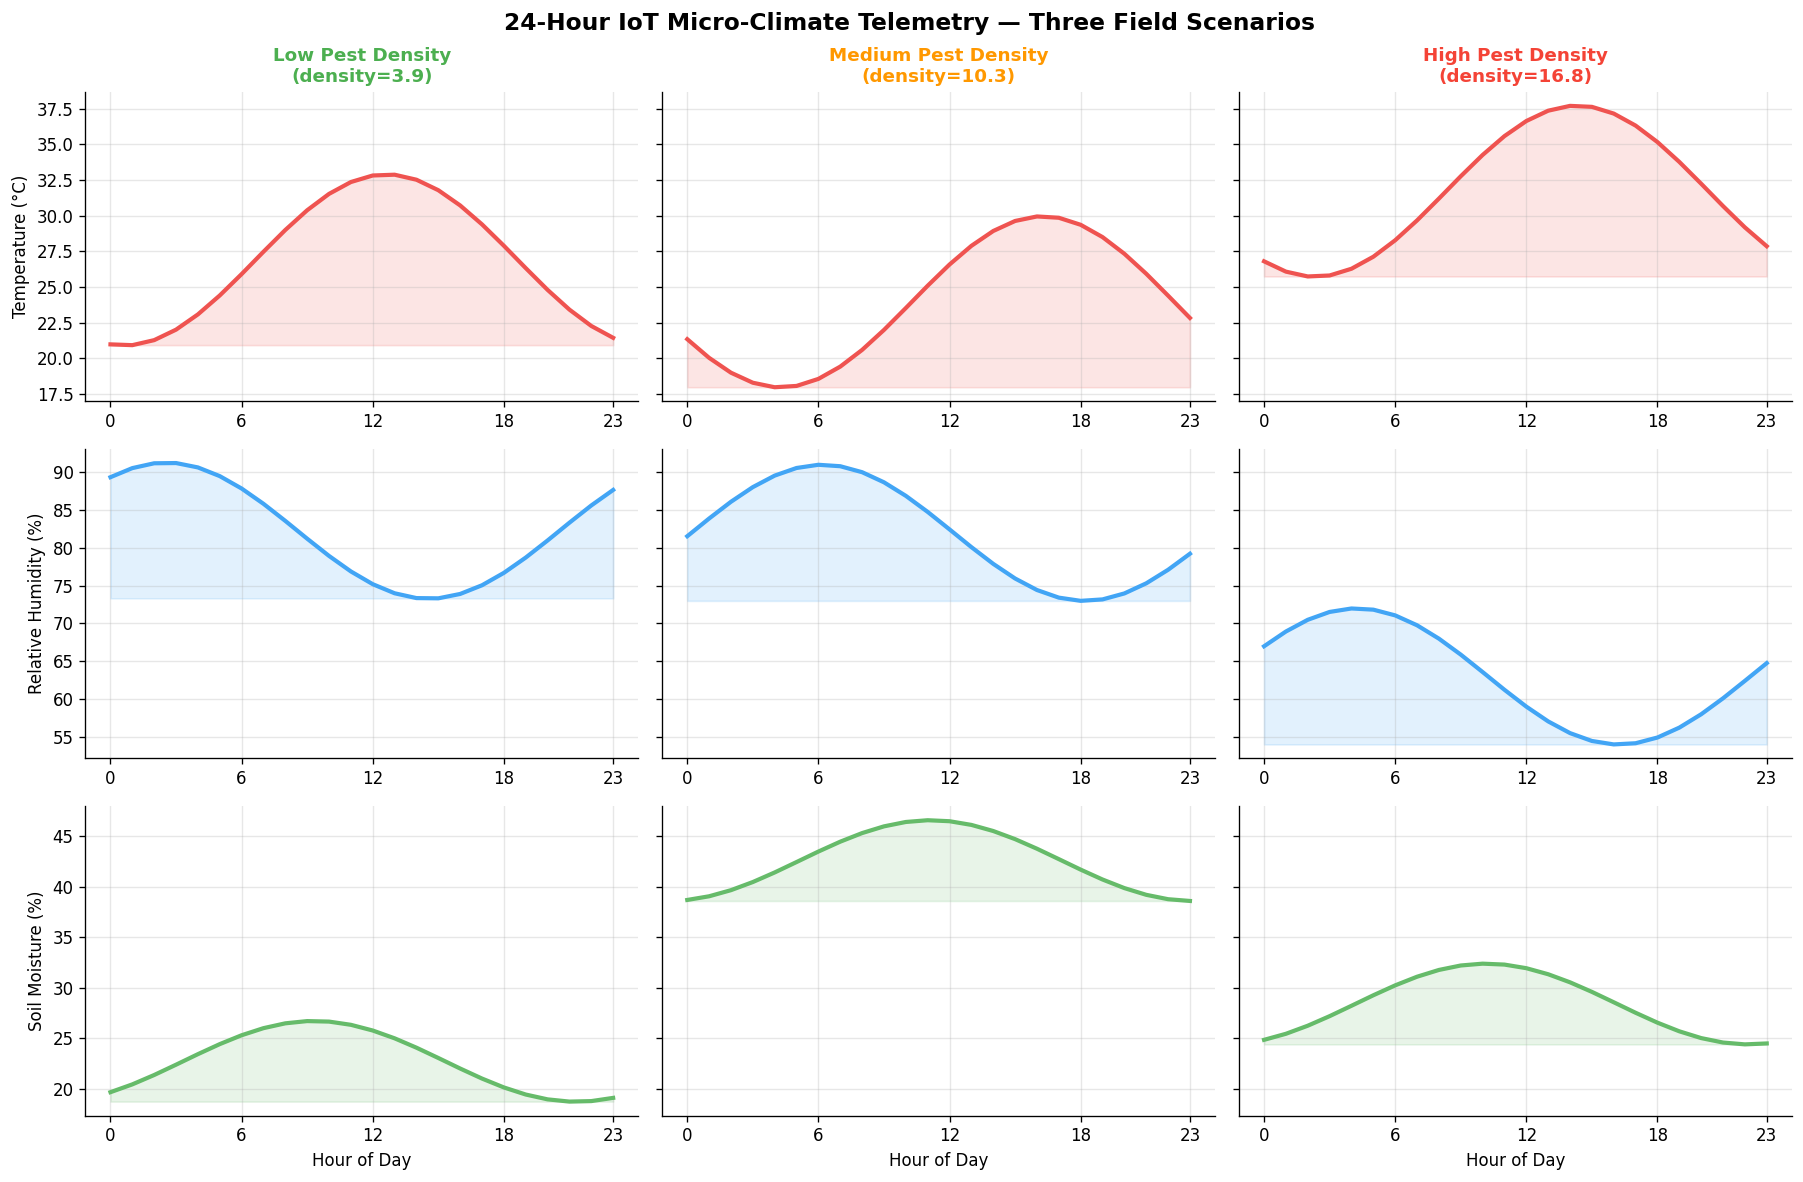

In [8]:
# Pick 3 representative samples: low / medium / high pest density
sample_indices = sorted(range(len(eval_ds)), key=lambda i: eval_ds[i]['density'].item())
chosen = [
    sample_indices[len(sample_indices) // 10],   # low density
    sample_indices[len(sample_indices) // 2],    # medium
    sample_indices[-len(sample_indices) // 10],  # high density
]
density_labels = ['Low Pest Density', 'Medium Pest Density', 'High Pest Density']
line_colors    = ['#4CAF50', '#FF9800', '#F44336']

hours = np.arange(TELEMETRY_T)
feature_names = ['Temperature (°C)', 'Relative Humidity (%)', 'Soil Moisture (%)']
feature_colors = ['#EF5350', '#42A5F5', '#66BB6A']

fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharey='row')

for col, (idx, dlabel, lc) in enumerate(zip(chosen, density_labels, line_colors)):
    sample = eval_ds[idx]
    tel    = sample['telemetry'].numpy()   # (24, 3)
    dens   = sample['density'].item()

    for row, (fname, fcolor) in enumerate(zip(feature_names, feature_colors)):
        ax = axes[row][col]
        ax.plot(hours, tel[:, row], color=fcolor, linewidth=2.5)
        ax.fill_between(hours, tel[:, row].min(), tel[:, row], alpha=0.15, color=fcolor)
        if row == 0:
            ax.set_title(f'{dlabel}\n(density={dens:.1f})', fontsize=11, fontweight='bold', color=lc)
        if col == 0:
            ax.set_ylabel(fname, fontsize=10)
        if row == 2:
            ax.set_xlabel('Hour of Day', fontsize=10)
        ax.set_xticks([0, 6, 12, 18, 23])

plt.suptitle('24-Hour IoT Micro-Climate Telemetry — Three Field Scenarios', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig3_telemetry.png', bbox_inches='tight')
plt.show()

## 📊 Figure 4 — UAV Image Samples
Synthetic UAV-like crop images. More red spots = higher pest pressure.

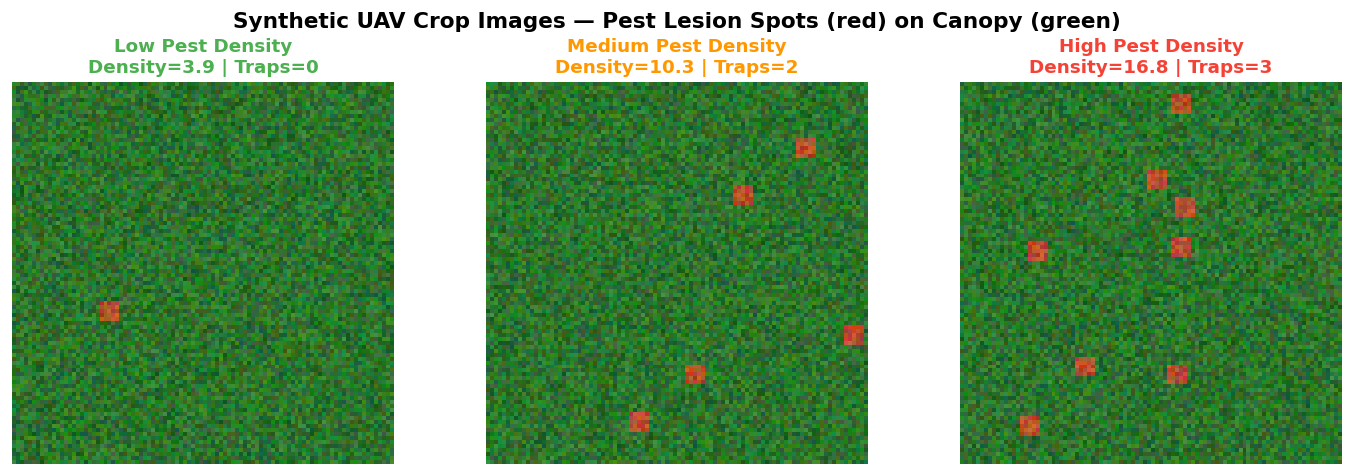

In [9]:
# De-normalize helper (ImageNet stats)
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denorm(t: Tensor) -> np.ndarray:
    return ((t * STD + MEAN).clamp(0, 1).permute(1, 2, 0).numpy())

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (idx, dlabel, lc) in zip(axes, zip(chosen, density_labels, line_colors)):
    sample = eval_ds[idx]
    img    = denorm(sample['image'])
    dens   = sample['density'].item()
    traps  = sample['trap_count'].item()

    ax.imshow(img)
    ax.set_title(f'{dlabel}\nDensity={dens:.1f} | Traps={traps:.0f}',
                 fontsize=11, fontweight='bold', color=lc)
    ax.axis('off')
    # Border color matches density severity
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(lc)
        spine.set_linewidth(3)

plt.suptitle('Synthetic UAV Crop Images — Pest Lesion Spots (red) on Canopy (green)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig4_uav_images.png', bbox_inches='tight')
plt.show()

## 📊 Figure 5 — Grad-CAM Spatial Attribution (XAI)
Shows *where* in the UAV image the model focused its attention for each prediction.

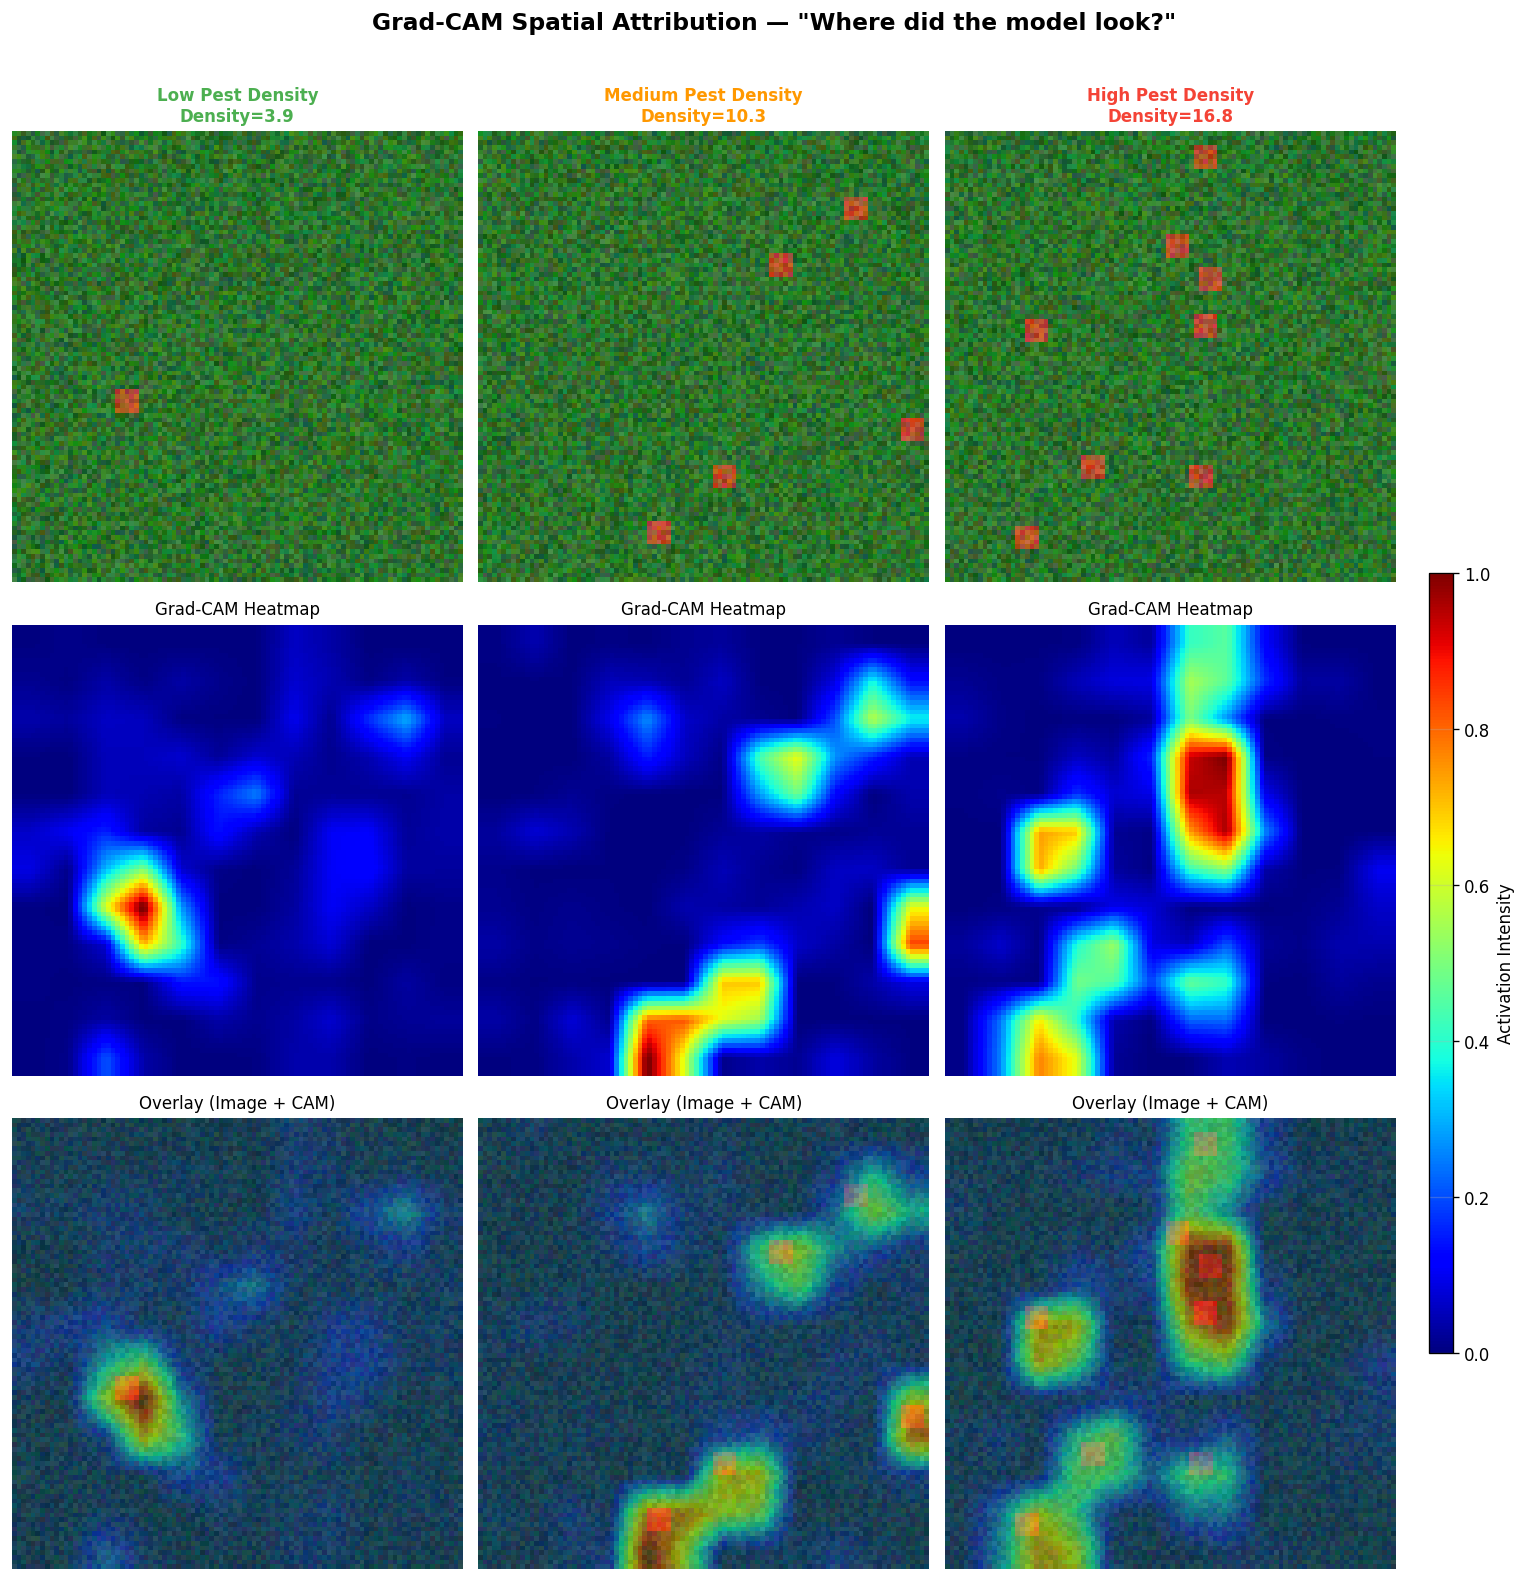

In [10]:
def compute_gradcam(sample: dict, device: torch.device) -> np.ndarray:
    # Must be in train mode (not no_grad) so retain_grad works
    model.eval()
    model.zero_grad(set_to_none=True)
    img  = sample['image'].unsqueeze(0).to(device)
    tel  = sample['telemetry'].unsqueeze(0).to(device)
    trap = sample['trap_count'].unsqueeze(0).to(device)
    # Do NOT use torch.no_grad() here — we need gradients for Grad-CAM
    pred, fmap, _ = model(img, tel, trap, return_fmap=True)
    pred.sum().backward()
    cam = (fmap.grad.mean((2, 3), keepdim=True) * fmap).sum(1, keepdim=True).relu()
    cam = F.interpolate(cam, size=img.shape[-2:], mode='bilinear', align_corners=False)[0, 0]
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam.detach().cpu().numpy()


fig, axes = plt.subplots(3, 3, figsize=(13, 13))

for col, (idx, dlabel, lc) in enumerate(zip(chosen, density_labels, line_colors)):
    sample = eval_ds[idx]
    img_np = denorm(sample['image'])
    cam_np = compute_gradcam(sample, DEVICE)
    dens   = sample['density'].item()

    # Row 0: original image
    axes[0][col].imshow(img_np)
    axes[0][col].set_title(f'{dlabel}\nDensity={dens:.1f}', fontsize=10, fontweight='bold', color=lc)
    axes[0][col].axis('off')

    # Row 1: Grad-CAM heatmap
    axes[1][col].imshow(cam_np, cmap='jet', vmin=0, vmax=1)
    axes[1][col].set_title('Grad-CAM Heatmap', fontsize=10)
    axes[1][col].axis('off')

    # Row 2: Overlay
    axes[2][col].imshow(img_np)
    axes[2][col].imshow(cam_np, cmap='jet', alpha=0.45, vmin=0, vmax=1)
    axes[2][col].set_title('Overlay (Image + CAM)', fontsize=10)
    axes[2][col].axis('off')

# Shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.5])
sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(0, 1))
fig.colorbar(sm, cax=cbar_ax, label='Activation Intensity')

plt.suptitle('Grad-CAM Spatial Attribution — "Where did the model look?"',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig(OUTPUT_DIR / 'fig5_gradcam.png', bbox_inches='tight')
plt.show()

## 📊 Figure 6 — SHAP Environmental Feature Importance (XAI)
Permutation-based sensitivity: how much does each IoT sensor feature drive the prediction?

Feature Importance (absolute):
  Temperature (°C)         : 0.0484
  Relative Humidity (%)    : 0.0494
  Soil Moisture (%)        : 0.0288


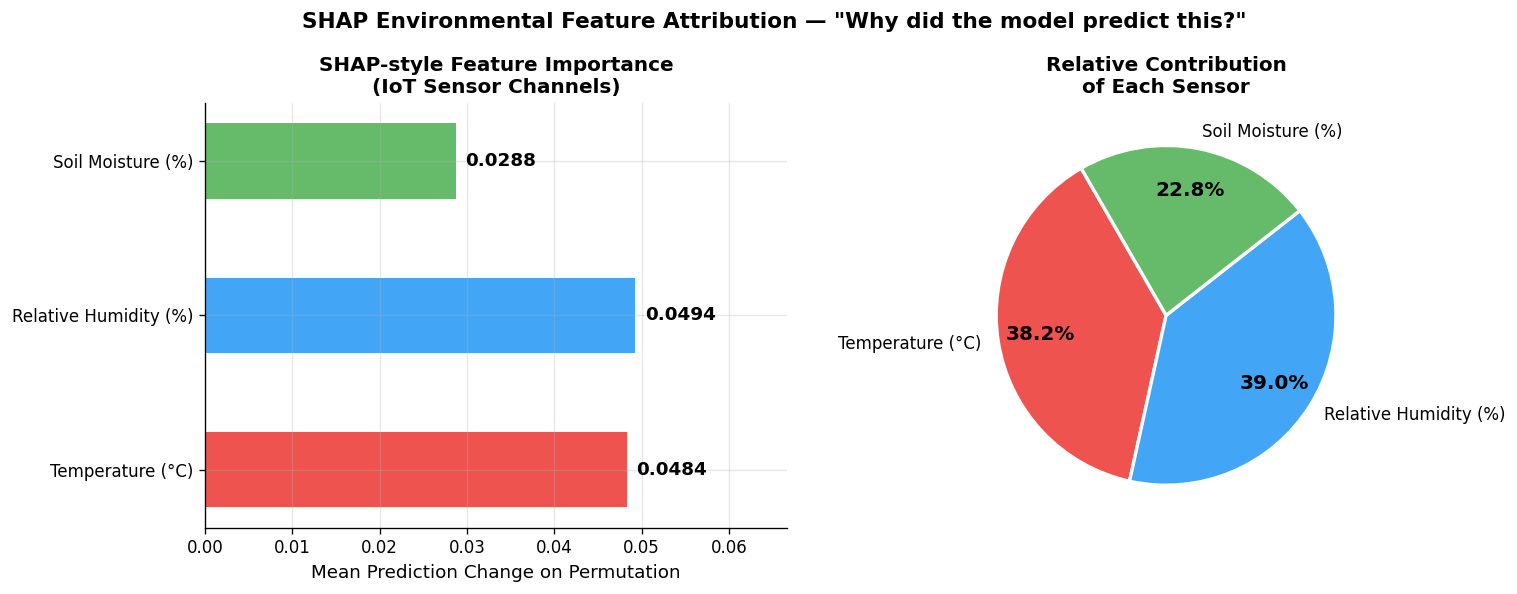

In [11]:
FEATURE_NAMES = ['Temperature (°C)', 'Relative Humidity (%)', 'Soil Moisture (%)']

@torch.no_grad()
def shap_importance(images: Tensor, telemetry: Tensor, traps: Tensor, repeats: int = 8) -> np.ndarray:
    """Permutation-based feature importance across a mini-batch."""
    model.eval()
    baseline = model(images, telemetry, traps).detach()
    importance = []
    for feat in range(telemetry.shape[-1]):
        deltas = []
        for _ in range(repeats):
            perturbed = telemetry.clone()
            perm = torch.randperm(perturbed.shape[0])
            perturbed[:, :, feat] = perturbed[perm, :, feat]
            delta = (baseline - model(images, perturbed, traps).detach()).abs().mean().item()
            deltas.append(delta)
        importance.append(float(np.mean(deltas)))
    return np.array(importance)


# Compute on a larger batch for stability
big_batch = next(iter(DataLoader(eval_ds, batch_size=64, shuffle=False)))
imgs  = big_batch['image'].to(DEVICE)
tels  = big_batch['telemetry'].to(DEVICE)
traps = big_batch['trap_count'].to(DEVICE)

imp = shap_importance(imgs, tels, traps, repeats=10)
imp_norm = imp / imp.sum()  # relative importance

print('Feature Importance (absolute):')
for name, val in zip(FEATURE_NAMES, imp):
    print(f'  {name:25s}: {val:.4f}')


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: horizontal bar chart ─────────────────────────────────────────────────
ax = axes[0]
bar_colors = ['#EF5350', '#42A5F5', '#66BB6A']
bars = ax.barh(FEATURE_NAMES, imp, color=bar_colors, edgecolor='white', linewidth=1.2, height=0.5)
for bar, val in zip(bars, imp):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Mean Prediction Change on Permutation', fontsize=11)
ax.set_title('SHAP-style Feature Importance\n(IoT Sensor Channels)', fontsize=12, fontweight='bold')
ax.set_xlim(0, imp.max() * 1.35)

# ── Right: pie chart ───────────────────────────────────────────────────────────
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    imp_norm, labels=FEATURE_NAMES, autopct='%1.1f%%',
    colors=bar_colors, startangle=120, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax2.set_title('Relative Contribution\nof Each Sensor', fontsize=12, fontweight='bold')

plt.suptitle('SHAP Environmental Feature Attribution — "Why did the model predict this?"',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig6_shap_importance.png', bbox_inches='tight')
plt.show()

## 📊 Figure 7 — Edge Deployment Benchmark
INT8 dynamic quantization simulates deployment on UAV-side compute or resource-constrained IoT nodes.

FP32: 0.369 ms/frame  |  0.64 MB
INT8: 0.569 ms/frame  |  0.34 MB
Speedup: 0.65x  |  Size reduction: 1.89x


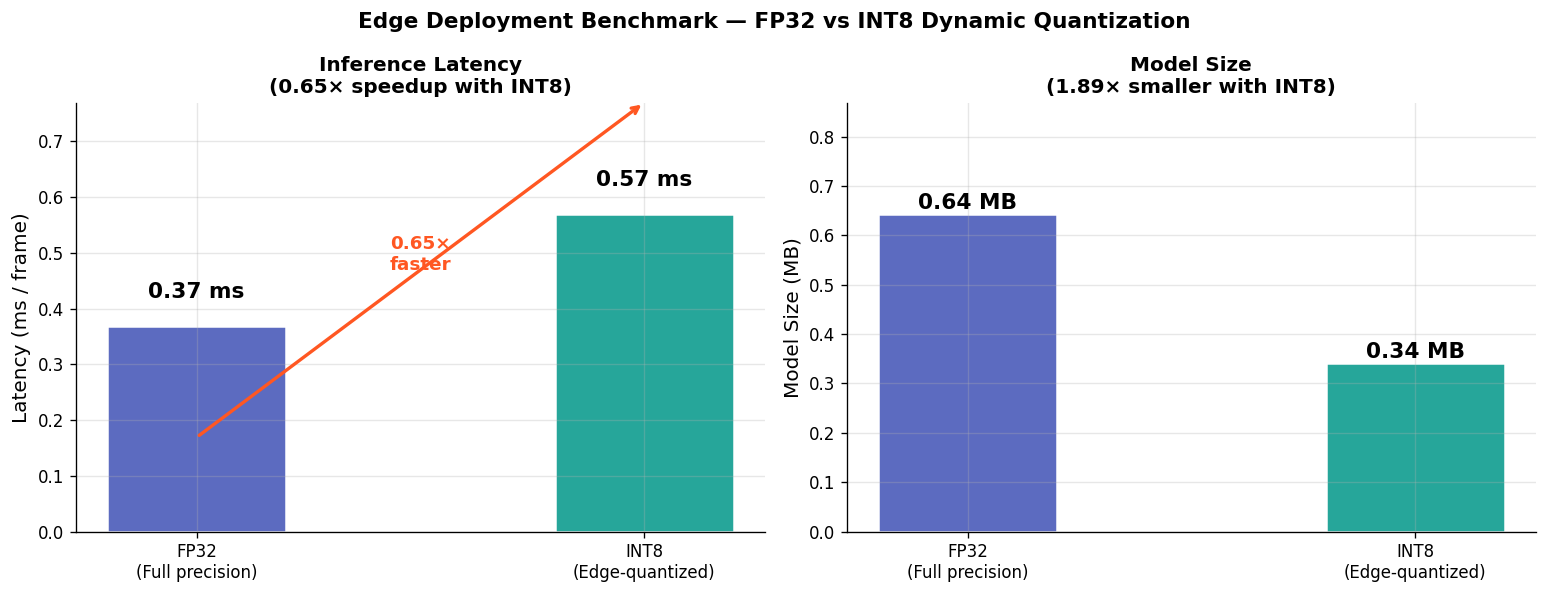

In [12]:
import copy

# ── Full FP32 latency ──────────────────────────────────────────────────────────
fp32_model = copy.deepcopy(model).cpu().eval()
bench_batch = next(iter(DataLoader(eval_ds, batch_size=BATCH_SIZE, shuffle=False)))
bench_img  = bench_batch['image'].cpu()
bench_tel  = bench_batch['telemetry'].cpu()
bench_trap = bench_batch['trap_count'].cpu()
N          = bench_img.shape[0]

# Warmup
with torch.inference_mode():
    for _ in range(3):
        _ = fp32_model(bench_img, bench_tel, bench_trap)

RUNS = 20
t0 = time.perf_counter()
with torch.inference_mode():
    for _ in range(RUNS):
        fp32_pred = fp32_model(bench_img, bench_tel, bench_trap)
fp32_ms = (time.perf_counter() - t0) * 1000 / (RUNS * N)

# ── INT8 quantized latency ─────────────────────────────────────────────────────
int8_model = torch.ao.quantization.quantize_dynamic(
    copy.deepcopy(model).cpu().eval(), {nn.LSTM, nn.Linear}, dtype=torch.qint8
)

with torch.inference_mode():
    for _ in range(3):
        _ = int8_model(bench_img, bench_tel, bench_trap)

t0 = time.perf_counter()
with torch.inference_mode():
    for _ in range(RUNS):
        int8_pred = int8_model(bench_img, bench_tel, bench_trap)
int8_ms = (time.perf_counter() - t0) * 1000 / (RUNS * N)

# ── Model sizes ────────────────────────────────────────────────────────────────
torch.save(fp32_model.state_dict(), OUTPUT_DIR / '_tmp_fp32.pt')
torch.save(int8_model.state_dict(), OUTPUT_DIR / '_tmp_int8.pt')
fp32_mb = (OUTPUT_DIR / '_tmp_fp32.pt').stat().st_size / 1e6
int8_mb = (OUTPUT_DIR / '_tmp_int8.pt').stat().st_size / 1e6
(OUTPUT_DIR / '_tmp_fp32.pt').unlink()
(OUTPUT_DIR / '_tmp_int8.pt').unlink()

speedup = fp32_ms / int8_ms
print(f'FP32: {fp32_ms:.3f} ms/frame  |  {fp32_mb:.2f} MB')
print(f'INT8: {int8_ms:.3f} ms/frame  |  {int8_mb:.2f} MB')
print(f'Speedup: {speedup:.2f}x  |  Size reduction: {fp32_mb/int8_mb:.2f}x')


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: latency bar ─────────────────────────────────────────────────────────
ax = axes[0]
labels  = ['FP32\n(Full precision)', 'INT8\n(Edge-quantized)']
latency = [fp32_ms, int8_ms]
colors  = ['#5C6BC0', '#26A69A']
bars = ax.bar(labels, latency, color=colors, width=0.4, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, latency):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{val:.2f} ms', ha='center', fontsize=13, fontweight='bold')
ax.set_ylabel('Latency (ms / frame)', fontsize=12)
ax.set_title(f'Inference Latency\n({speedup:.2f}× speedup with INT8)', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(latency) * 1.35)

# Annotate speedup arrow
ax.annotate('', xy=(1, int8_ms + 0.2), xytext=(0, fp32_ms - 0.2),
            arrowprops=dict(arrowstyle='->', color='#FF5722', lw=2))
ax.text(0.5, (fp32_ms + int8_ms) / 2, f'{speedup:.2f}×\nfaster',
        ha='center', fontsize=11, color='#FF5722', fontweight='bold')

# ── Right: model size bar ─────────────────────────────────────────────────────
ax2 = axes[1]
sizes = [fp32_mb, int8_mb]
bars2 = ax2.bar(labels, sizes, color=colors, width=0.4, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, sizes):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{val:.2f} MB', ha='center', fontsize=13, fontweight='bold')
ax2.set_ylabel('Model Size (MB)', fontsize=12)
ax2.set_title(f'Model Size\n({fp32_mb/int8_mb:.2f}× smaller with INT8)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, max(sizes) * 1.35)

plt.suptitle('Edge Deployment Benchmark — FP32 vs INT8 Dynamic Quantization',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig7_edge_benchmark.png', bbox_inches='tight')
plt.show()

## 📊 Figure 8 — System Architecture Diagram
Visual summary of the full multimodal pipeline.

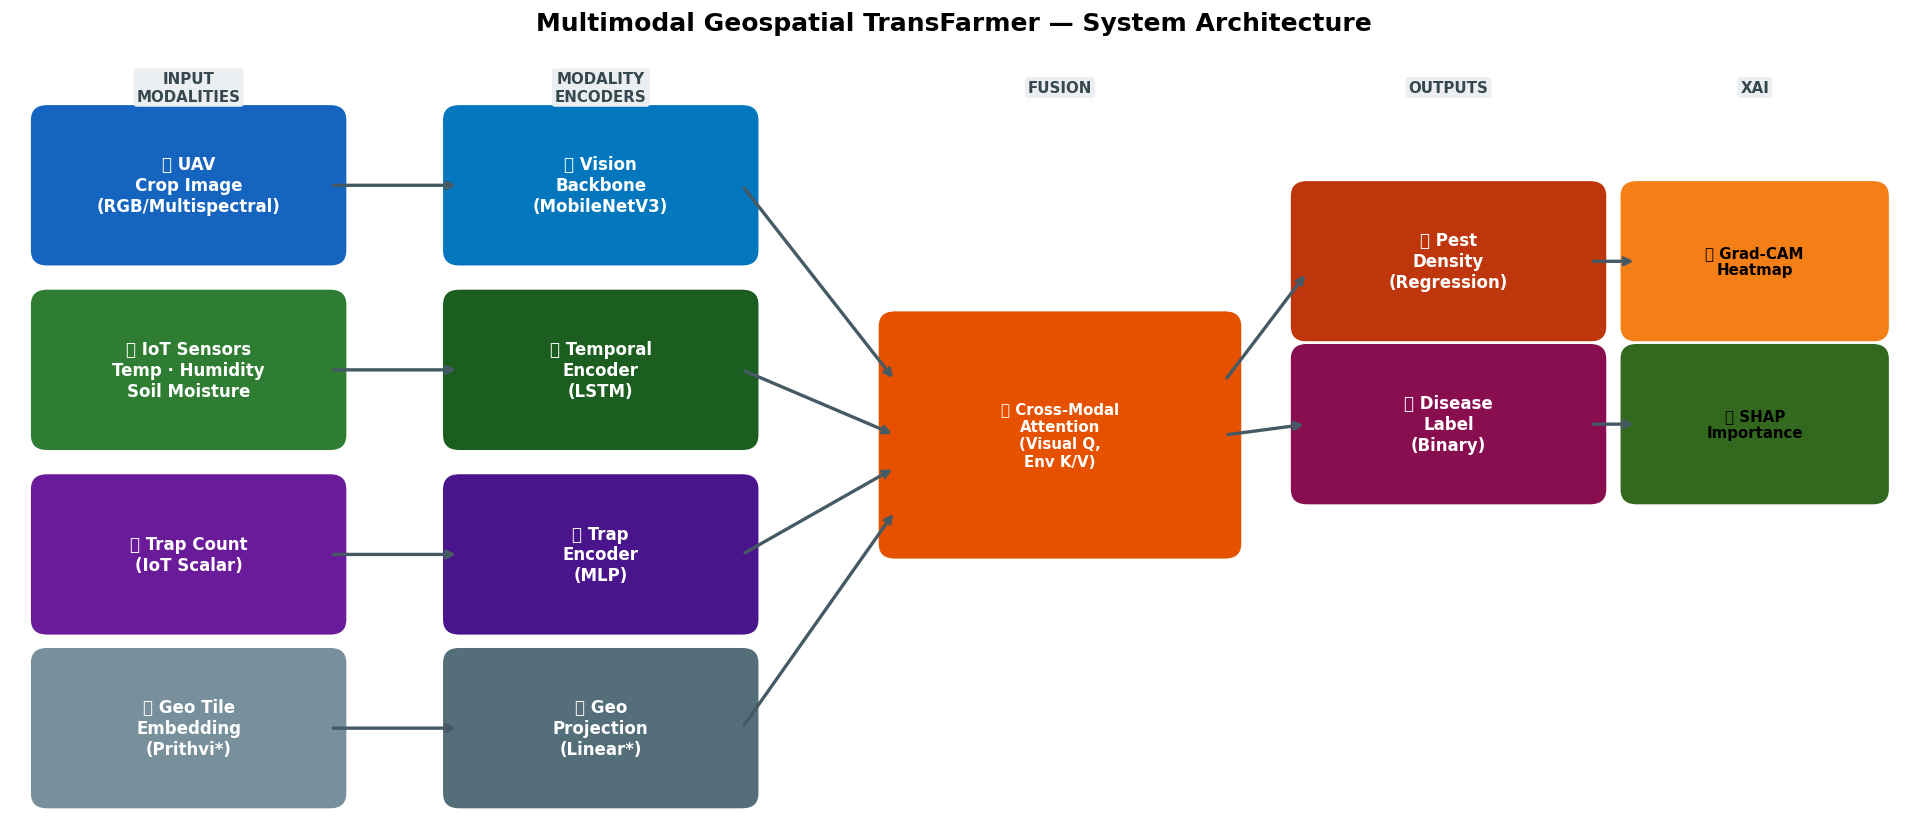

In [13]:
fig, ax = plt.subplots(figsize=(16, 7))
ax.set_xlim(0, 16)
ax.set_ylim(0, 7)
ax.axis('off')

def box(ax, x, y, w, h, text, facecolor, textcolor='white', fontsize=10):
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.15',
                                    facecolor=facecolor, edgecolor='white', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=fontsize, color=textcolor, fontweight='bold', wrap=True,
            multialignment='center')

def arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#455A64', lw=2.0))

# ── Input layer ───────────────────────────────────────────────────────────────
box(ax, 0.3, 5.2, 2.4, 1.2, '🛸 UAV\nCrop Image\n(RGB/Multispectral)', '#1565C0')
box(ax, 0.3, 3.5, 2.4, 1.2, '🌡 IoT Sensors\nTemp · Humidity\nSoil Moisture', '#2E7D32')
box(ax, 0.3, 1.8, 2.4, 1.2, '📡 Trap Count\n(IoT Scalar)', '#6A1B9A')
box(ax, 0.3, 0.2, 2.4, 1.2, '🛰 Geo Tile\nEmbedding\n(Prithvi*)', '#78909C', textcolor='white')

# ── Encoder layer ─────────────────────────────────────────────────────────────
box(ax, 3.8, 5.2, 2.4, 1.2, '🔬 Vision\nBackbone\n(MobileNetV3)', '#0277BD')
box(ax, 3.8, 3.5, 2.4, 1.2, '⏱ Temporal\nEncoder\n(LSTM)', '#1B5E20')
box(ax, 3.8, 1.8, 2.4, 1.2, '📊 Trap\nEncoder\n(MLP)', '#4A148C')
box(ax, 3.8, 0.2, 2.4, 1.2, '🗺 Geo\nProjection\n(Linear*)', '#546E7A', textcolor='white')

# ── Fusion layer ──────────────────────────────────────────────────────────────
box(ax, 7.5, 2.5, 2.8, 2.0, '🔗 Cross-Modal\nAttention\n(Visual Q,\nEnv K/V)', '#E65100', fontsize=9)

# ── Output layer ─────────────────────────────────────────────────────────────
box(ax, 11.0, 4.5, 2.4, 1.2, '📈 Pest\nDensity\n(Regression)', '#BF360C')
box(ax, 11.0, 3.0, 2.4, 1.2, '🦠 Disease\nLabel\n(Binary)', '#880E4F')

# ── XAI layer ────────────────────────────────────────────────────────────────
box(ax, 13.8, 4.5, 2.0, 1.2, '🔥 Grad-CAM\nHeatmap', '#F57F17', textcolor='black', fontsize=9)
box(ax, 13.8, 3.0, 2.0, 1.2, '📊 SHAP\nImportance', '#33691E', textcolor='black', fontsize=9)

# ── Arrows: inputs → encoders ─────────────────────────────────────────────────
for y in [5.8, 4.1, 2.4, 0.8]:
    arrow(ax, 2.7, y, 3.8, y)

# ── Arrows: encoders → fusion ─────────────────────────────────────────────────
arrow(ax, 6.2, 5.8, 7.5, 4.0)
arrow(ax, 6.2, 4.1, 7.5, 3.5)
arrow(ax, 6.2, 2.4, 7.5, 3.2)
arrow(ax, 6.2, 0.8, 7.5, 2.8)

# ── Arrows: fusion → outputs ──────────────────────────────────────────────────
arrow(ax, 10.3, 4.0, 11.0, 5.0)
arrow(ax, 10.3, 3.5, 11.0, 3.6)

# ── Arrows: outputs → XAI ────────────────────────────────────────────────────
arrow(ax, 13.4, 5.1, 13.8, 5.1)
arrow(ax, 13.4, 3.6, 13.8, 3.6)

# ── Labels ───────────────────────────────────────────────────────────────────
for x, label, color in [
    (1.5, 'INPUT\nMODALITIES', '#37474F'),
    (5.0, 'MODALITY\nENCODERS', '#37474F'),
    (8.9, 'FUSION', '#37474F'),
    (12.2, 'OUTPUTS', '#37474F'),
    (14.8, 'XAI', '#37474F'),
]:
    ax.text(x, 6.7, label, ha='center', va='center', fontsize=9,
            color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#ECEFF1', edgecolor='none'))

ax.text(0.55, 0.45, '* Prithvi\nintegration\nplanned', fontsize=7, color='#78909C',
        style='italic')

plt.title('Multimodal Geospatial TransFarmer — System Architecture',
          fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig8_architecture.png', bbox_inches='tight', dpi=150)
plt.show()

## 📊 Figure 9 — Cross-Modal Attention Weight Visualization
Shows how much each visual spatial patch attends to each environmental context token.

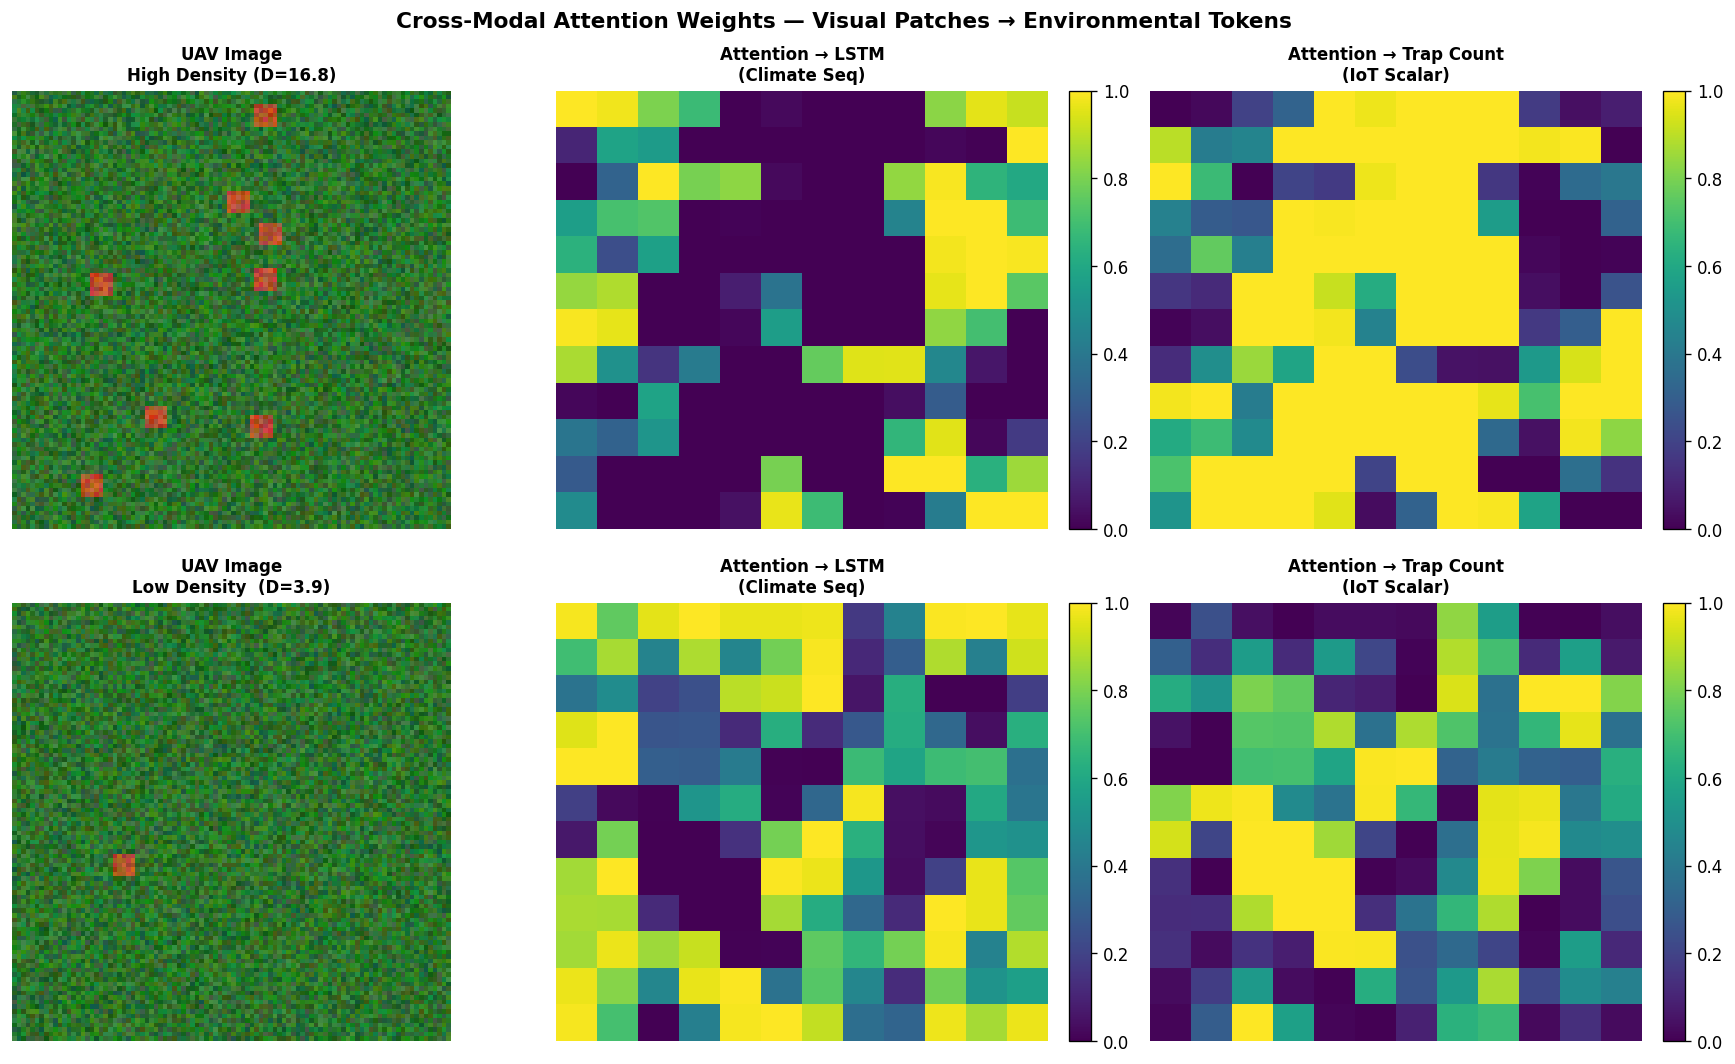

In [14]:
model.eval()
sample_hi  = eval_ds[chosen[2]]   # high density sample
sample_lo  = eval_ds[chosen[0]]   # low density sample

def get_attention_map(sample, device):
    """Extract cross-modal attention weights without needing gradients."""
    img  = sample['image'].unsqueeze(0).to(device)
    tel  = sample['telemetry'].unsqueeze(0).to(device)
    trap = sample['trap_count'].unsqueeze(0).to(device)
    with torch.no_grad():
        # return_fmap=False — we only need attn weights, no retain_grad needed
        pred = model(img, tel, trap, return_fmap=False)
        # Re-run fusion manually to grab attention weights
        fmap = model.vision(img)
        vis_tok = fmap.flatten(2).transpose(1, 2)
        _, (h, _) = model.lstm(tel)
        env = torch.stack([h[-1], model.trap_enc(trap)], dim=1)
        _, attn_w = model.fusion(vis_tok, env)
    # attn_w: (1, N_visual, 2) — 2 env tokens: LSTM hidden + trap
    return attn_w[0].cpu().numpy()   # (N_visual, 2)

attn_hi = get_attention_map(sample_hi, DEVICE)
attn_lo = get_attention_map(sample_lo, DEVICE)

spatial_size = int(np.sqrt(attn_hi.shape[0]))  # e.g. 12 for 96/8

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
token_labels = ['LSTM\n(Climate Seq)', 'Trap Count\n(IoT Scalar)']
row_labels   = [
    f'High Density (D={sample_hi["density"].item():.1f})',
    f'Low Density  (D={sample_lo["density"].item():.1f})'
]

for row_i, (attn, sample, rl) in enumerate([
    (attn_hi, sample_hi, row_labels[0]),
    (attn_lo, sample_lo, row_labels[1])
]):
    # Original image
    axes[row_i][0].imshow(denorm(sample['image']))
    axes[row_i][0].set_title(f'UAV Image\n{rl}', fontsize=10, fontweight='bold')
    axes[row_i][0].axis('off')

    # Attention to each env token
    for tok_i, tok_label in enumerate(token_labels):
        a_map = attn[:, tok_i].reshape(spatial_size, spatial_size)
        a_map = (a_map - a_map.min()) / (a_map.max() - a_map.min() + 1e-8)
        im = axes[row_i][tok_i + 1].imshow(a_map, cmap='viridis', aspect='auto')
        axes[row_i][tok_i + 1].set_title(f'Attention → {tok_label}', fontsize=10, fontweight='bold')
        axes[row_i][tok_i + 1].axis('off')
        plt.colorbar(im, ax=axes[row_i][tok_i + 1], fraction=0.046, pad=0.04)

plt.suptitle('Cross-Modal Attention Weights — Visual Patches → Environmental Tokens',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig9_attention_weights.png', bbox_inches='tight')
plt.show()